In [74]:
!pip install yfinance
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [1]:
import sys
print(sys.executable)

/home/eugene/Desktop/Python Projects/yfinance/.venv/bin/python


In [2]:
import sys
!{sys.executable} -m pip show scikit-learn

/bin/bash: line 1: /home/eugene/Desktop/Python: No such file or directory


In [15]:
import yfinance as yf
import pandas as pd
import datetime
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = yf.download("00646.tw", start="2020-01-01", end=datetime.datetime.today())
data



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,00646.TW,00646.TW,00646.TW,00646.TW,00646.TW
Date,,,,,
2020-01-02,29.639999,29.690001,29.549999,29.690001,92220
2020-01-03,29.620001,29.870001,29.590000,29.870001,281168
2020-01-06,29.500000,29.520000,29.410000,29.480000,1571736
2020-01-07,29.730000,29.740000,29.639999,29.639999,542303
2020-01-08,29.440001,29.500000,29.200001,29.219999,211590
...,...,...,...,...,...
2026-08-18,77.250000,77.900002,77.250000,77.900002,3751986
2026-08-19,77.099998,77.449997,76.949997,77.199997,2618927


In [16]:

data = pd.DataFrame(data)
data.dropna(subset = [("Close", "00646.TW")], inplace = True)
data

Price,Close,High,Low,Open,Volume
Ticker,00646.TW,00646.TW,00646.TW,00646.TW,00646.TW
Date,,,,,
2020-01-02,29.639999,29.690001,29.549999,29.690001,92220
2020-01-03,29.620001,29.870001,29.590000,29.870001,281168
2020-01-06,29.500000,29.520000,29.410000,29.480000,1571736
2020-01-07,29.730000,29.740000,29.639999,29.639999,542303
2020-01-08,29.440001,29.500000,29.200001,29.219999,211590
...,...,...,...,...,...
2026-08-18,77.250000,77.900002,77.250000,77.900002,3751986
2026-08-19,77.099998,77.449997,76.949997,77.199997,2618927


<Axes: xlabel='Date', ylabel='TWD'>

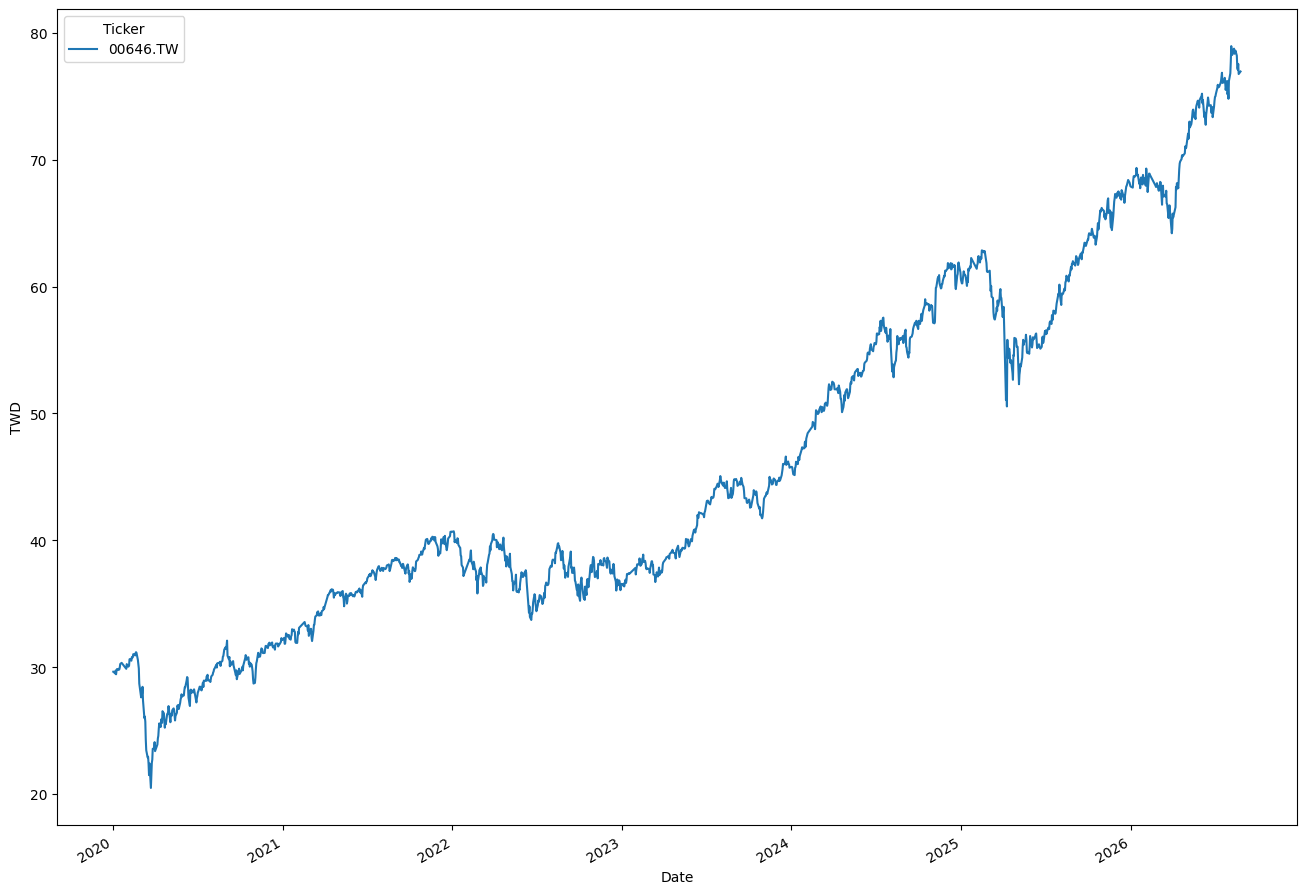

In [17]:
df = data["Close"]
df.dropna(inplace = True)
plot = df.plot(figsize = (16,12))
plot.set_ylabel("TWD")
plot

In [18]:
# data preparation
x = data.reset_index(names = "days")
x = np.arange(1, len(x["days"]) + 1)
y = data["Close"].values.ravel()

length = int(len(x) * 0.8) # only take 80% of data as training data

x_train = x[0: length] 
y_train = y[0: length]
x_validate = x[length:]
y_validate = y[length:]


Equation: y = 26.9242 * e^(0.0006 * x)


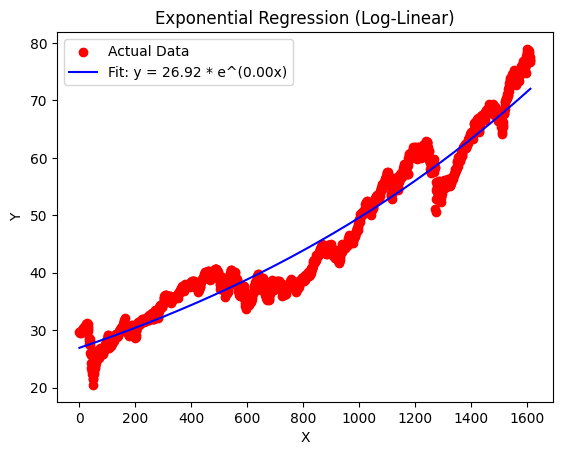

In [19]:
## first step: get a guess value p0 from a log trick

# use log trick to compute exponential regression

# Transform y using the natural logarithm
log_y = np.log(y)

# Fit a linear regression model
# (sklearn expects 2D array for features, so we reshape x)
model = LinearRegression()
model.fit(x.reshape(-1, 1), log_y)

# 4. Extract the coefficients
b = model.coef_[0]
a = np.exp(model.intercept_) # Convert back from log scale

print(f"Equation: y = {a:.4f} * e^({b:.4f} * x)")

# 5. Predict and Plot
y_pred = a * np.exp(b * x)

plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x, y_pred, color='blue', label=f'Fit: y = {a:.2f} * e^({b:.2f}x)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Exponential Regression (Log-Linear)')
plt.show()

Equation: y = 5.3053 * e^(0.0015 * x) + 24.153916303725744


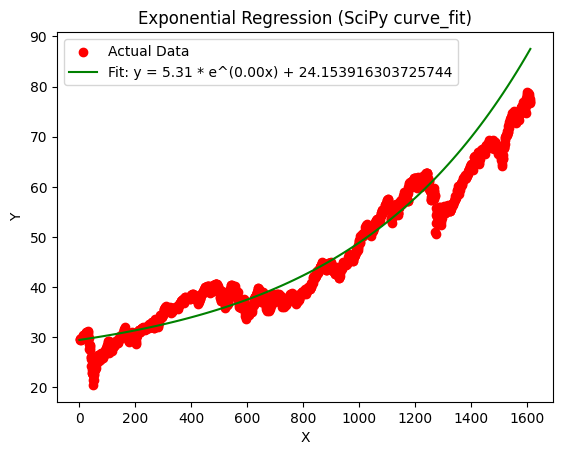

In [20]:
## second step: use the guess value p0 to perform exponential curve fit

# use scipy curve_fit()
# Define the exponential target function
def exponential_func(x, a, b, c):
    return a * np.exp(b * x) + c

initial_guess = [a, b, 40]

# Fit the curve
# curve_fit returns optimal parameters (popt) and their covariance (pcov)
popt, pcov = curve_fit(exponential_func, x_train, y_train, p0 = initial_guess, maxfev = 5000)

a_opt, b_opt, c_opt = popt
print(f"Equation: y = {a_opt:.4f} * e^({b_opt:.4f} * x) + {c_opt}")

# 4. Predict and Plot
x_fine = np.linspace(0, len(x), 100) # Smother line for the plot
y_pred = exponential_func(x_fine, a_opt, b_opt, c_opt)

plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x_fine, y_pred, color='green', label=f'Fit: y = {a_opt:.2f} * e^({b_opt:.2f}x) + {c_opt}')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Exponential Regression (SciPy curve_fit)')
plt.show()

In [21]:
#預測明天的價格
x = x[-1]
x = np.add(x, 1)
y_pred = exponential_func(x, a_opt, b_opt, c_opt)
print(y_pred)

87.59869426230838
